In [1]:
import numpy as np
import matplotlib.pyplot as plt

hbar, c, G, kB = 1.0546e-34, 2.998e8, 6.674e-11, 1.381e-23
Msun, Mmoon = 1.989e30, 7.346e22
yr = 3.156e7
T_CMB = 2.725

plt.rcParams['figure.dpi'] = 110

T_H  = lambda M: hbar*c**3/(8*np.pi*G*M*kB)          # hawking temperature [K]
S_BH = lambda M: 4*np.pi*G*M**2/(hbar*c)             # entropy in units of kB

for name, m in [("the sun, as a black hole", Msun),
                ("sagittarius a*", 4.3e6*Msun),
                ("m87*", 6.5e9*Msun)]:
    print(f"{name:<28} T = {T_H(m):.2e} K")

M_cross = hbar*c**3/(8*np.pi*G*kB*T_CMB)
print(f"\na black hole matches the CMB temperature ({T_CMB} K) at M = {M_cross:.2e} kg")
print(f"which is {M_cross/Mmoon:.2f} times the mass of the moon")

the sun, as a black hole     T = 6.17e-08 K
sagittarius a*               T = 1.43e-14 K
m87*                         T = 9.49e-18 K

a black hole matches the CMB temperature (2.725 K) at M = 4.50e+22 kg
which is 0.61 times the mass of the moon


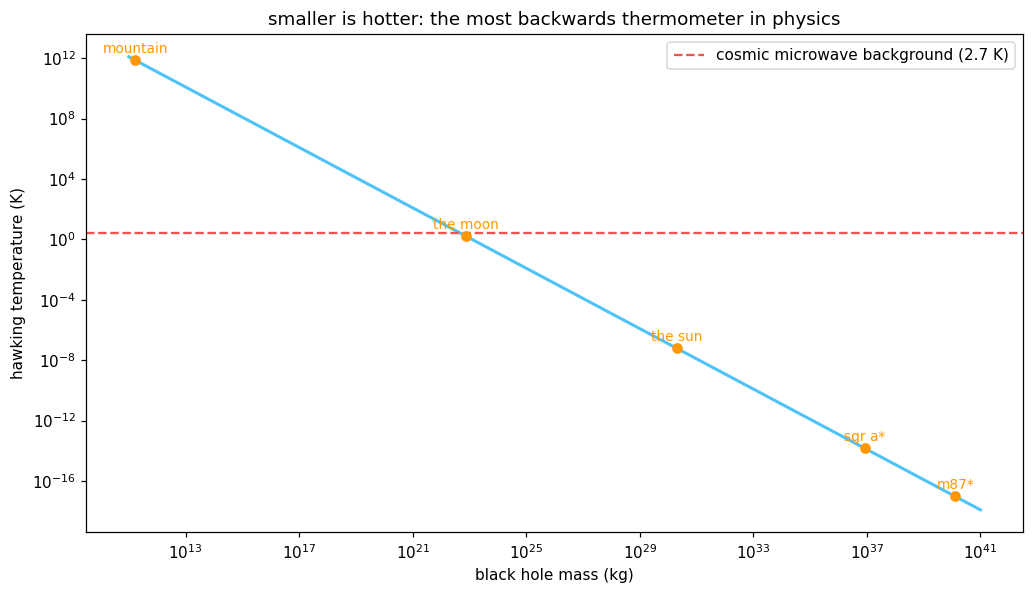

In [2]:
masses = np.logspace(11, 41, 500)
plt.figure(figsize=(9.5, 5.5))
plt.loglog(masses, T_H(masses), color='#4fc3f7', lw=2)
plt.axhline(T_CMB, color='#ef5350', ls='--', label='cosmic microwave background (2.7 K)')
for name, m, dy in [("mountain", 1.7e11, 3), ("the moon", Mmoon, 3),
                    ("the sun", Msun, 3), ("sgr a*", 4.3e6*Msun, 3), ("m87*", 6.5e9*Msun, 3)]:
    plt.plot(m, T_H(m), 'o', color='#ff9800')
    plt.annotate(name, (m, T_H(m)*dy), color='#ff9800', fontsize=9, ha='center')
plt.xlabel('black hole mass (kg)'); plt.ylabel('hawking temperature (K)')
plt.title('smaller is hotter: the most backwards thermometer in physics')
plt.legend(); plt.tight_layout(); plt.show()

In [3]:
S_sun_thermal = 1e58        # the actual sun, as hot gas (standard estimate, order of magnitude)
S_cmb_universe = 1e89       # all the light in the observable universe (ditto)

rows = [("the sun (as it is, hot gas)",      S_sun_thermal),
        ("the sun, collapsed to a black hole", S_BH(Msun)),
        ("sagittarius a*",                    S_BH(4.3e6*Msun)),
        ("m87*",                              S_BH(6.5e9*Msun)),
        ("every photon in the observable universe", S_cmb_universe)]
print(f"{'object':<44}{'entropy / kB':>14}")
for name, s in rows:
    print(f"{name:<44}{s:>14.1e}")
print(f"\ncollapsing the sun multiplies its entropy by {S_BH(Msun)/S_sun_thermal:.0e}")
print(f"m87* alone out-entropies all the light in the universe by {S_BH(6.5e9*Msun)/S_cmb_universe:.0e}x")

object                                        entropy / kB
the sun (as it is, hot gas)                        1.0e+58
the sun, collapsed to a black hole                 1.0e+77
sagittarius a*                                     1.9e+90
m87*                                               4.4e+96
every photon in the observable universe            1.0e+89

collapsing the sun multiplies its entropy by 1e+19
m87* alone out-entropies all the light in the universe by 4e+07x


In [4]:
t_evap = lambda M: 5120*np.pi*G**2*M**3/(hbar*c**4)
t_universe = 13.8e9*yr

print(f"lifetime of a solar-mass hole: {t_evap(Msun)/yr:.1e} years")
print(f"the universe is currently:     {t_universe/yr:.1e} years old")
print(f"fraction of itself a solar hole has evaporated since the big bang: {t_universe/(3*t_evap(Msun)):.0e}")

# a primordial hole finishing its evaporation *today* was born with:
M_dying = (hbar*c**4*t_universe/(5120*np.pi*G**2))**(1/3)
print(f"\na hole evaporating to nothing today was born at M = {M_dying:.1e} kg (a decent mountain)")
print(f"its temperature right now: {T_H(M_dying):.1e} K and climbing")

# its final act
M_1s = (hbar*c**4*1.0/(5120*np.pi*G**2))**(1/3)     # mass with one second left
print(f"\nwith one second to live it still weighs {M_1s:.1e} kg,")
print(f"and converts all of it to radiation: {M_1s*c**2:.1e} J = {M_1s*c**2/4.184e15:.1e} megatons of tnt")

lifetime of a solar-mass hole: 2.1e+67 years
the universe is currently:     1.4e+10 years old
fraction of itself a solar hole has evaporated since the big bang: 2e-58

a hole evaporating to nothing today was born at M = 1.7e+11 kg (a decent mountain)
its temperature right now: 7.1e+11 K and climbing

with one second to live it still weighs 2.3e+05 kg,
and converts all of it to radiation: 2.1e+22 J = 4.9e+06 megatons of tnt


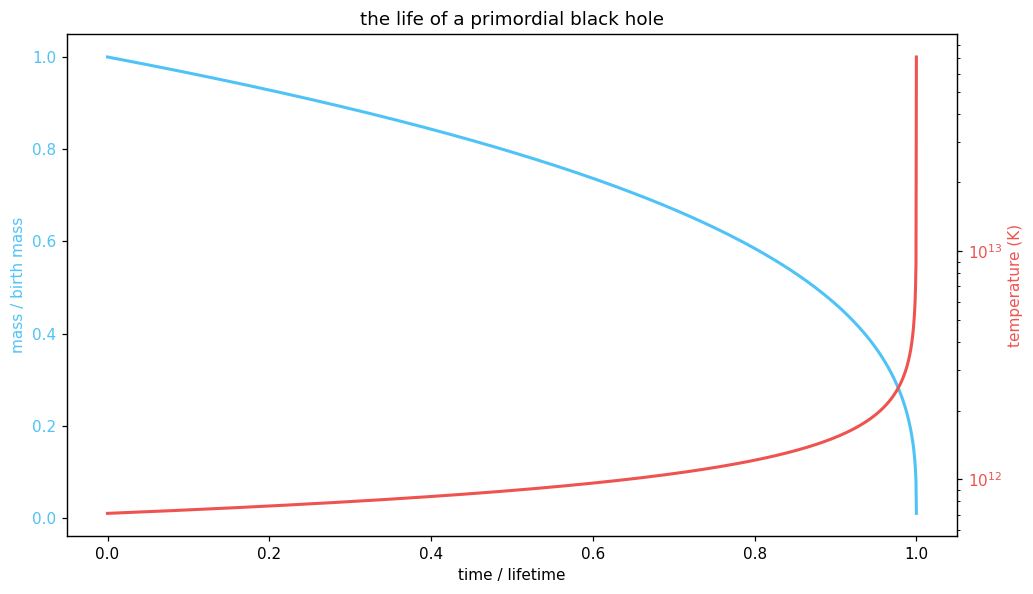

In [6]:
# the life story of a mountain-mass black hole, born at the big bang, dying today
M0 = M_dying
t = np.linspace(0, 0.999999*t_evap(M0), 2000)
Mt = M0*(1 - t/t_evap(M0))**(1/3)

fig, ax1 = plt.subplots(figsize=(9.5, 5.5))
ax1.plot(t/t_evap(M0), Mt/M0, color='#4fc3f7', lw=2)
ax1.set_xlabel('time / lifetime'); ax1.set_ylabel('mass / birth mass', color='#4fc3f7')
ax1.tick_params(axis='y', labelcolor='#4fc3f7')
ax2 = ax1.twinx()
ax2.semilogy(t/t_evap(M0), T_H(Mt), color='#ef5350', lw=2)
ax2.set_ylabel('temperature (K)', color='#ef5350')
ax2.tick_params(axis='y', labelcolor='#ef5350')
plt.title('the life of a primordial black hole')
plt.tight_layout(); plt.show()

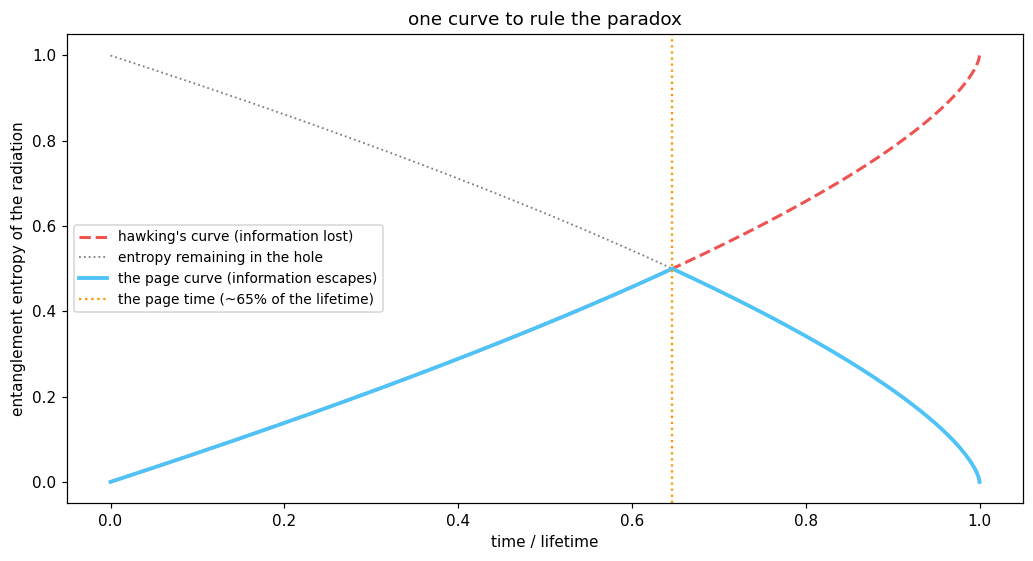

In [7]:
tau = np.linspace(0, 1, 1000)
S_hole = (1 - tau)**(2/3)             # hole's entropy ~ M^2, in units of the initial entropy
S_rad_hawking = 1 - S_hole            # radiated entropy, if it really is featureless noise
S_page = np.minimum(S_rad_hawking, S_hole)
tau_page = 1 - 2**-1.5

plt.figure(figsize=(9.5, 5.2))
plt.plot(tau, S_rad_hawking, color='#ef5350', lw=2, ls='--',
         label="hawking's curve (information lost)")
plt.plot(tau, S_hole, color='gray', lw=1.2, ls=':', label="entropy remaining in the hole")
plt.plot(tau, S_page, color='#4fc3f7', lw=2.5, label="the page curve (information escapes)")
plt.axvline(tau_page, color='#ff9800', ls=':',
            label=f'the page time (~{100*tau_page:.0f}% of the lifetime)')
plt.xlabel('time / lifetime'); plt.ylabel('entanglement entropy of the radiation')
plt.title('one curve to rule the paradox')
plt.legend(fontsize=9); plt.tight_layout(); plt.show()